In [1]:
# Step 1: Check we have a GPU
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU found. Go to Runtime -> Change runtime type -> T4 GPU')

CUDA available: True
GPU: Tesla T4


In [3]:
# Step 2: Clone the repo
!git clone https://github.com/kaiD-ops/caal2026.git
%cd caal2026

Cloning into 'caal2026'...
remote: Enumerating objects: 264, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 264 (delta 16), reused 41 (delta 10), pack-reused 216 (from 1)
Receiving objects: 100% (264/264), 210.56 MiB | 39.82 MiB/s, done.
Resolving deltas: 100% (44/44), done.
/kaggle/working/caal2026


In [4]:
# Step 3: Install dependencies
!pip install einops torchinfo git+https://github.com/mwalmsley/galaxy_mnist.git -q

  Preparing metadata (setup.py) ... done


In [5]:
# Step 4: Retrain the model


import os
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

from model import GalaxyClassifierS4D
from model.functions import export_model_parameters, load_data


# Settings
# RNG_SEED is the team ERP ID - keeps train/val split consistent

RNG_SEED   = 29070
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
COLORED    = False      # grayscale images
BATCH_SIZE = 64
EPOCHS     = 25         # was 15 before, still improving at epoch 14
LR         = 0.0015
CHECKPOINT = 'model_params/galaxys4-29070.pth'

torch.manual_seed(RNG_SEED)
np.random.seed(RNG_SEED)
print(f'Device: {DEVICE}')
print(f'Epochs: {EPOCHS} | LR: {LR} | Batch: {BATCH_SIZE}')

Device: cuda
Epochs: 25 | LR: 0.0015 | Batch: 64


In [7]:
import os
import shutil

# uploaded datasets go to /kaggle/input/
os.makedirs('./data/GalaxyMNIST/raw', exist_ok=True)

# Copy from Kaggle input to expected location
for root, dirs, files in os.walk('/kaggle/input/'):
    for fname in files:
        if fname.endswith('.hdf5'):
            src = os.path.join(root, fname)
            dst = f'./data/GalaxyMNIST/raw/{fname}'
            shutil.copy(src, dst)
            print(f'Copied: {src} -> {dst}')

Copied: /kaggle/input/datasets/mustafaghani/train-and-test-data-sets/train_dataset.hdf5 -> ./data/GalaxyMNIST/raw/train_dataset.hdf5
Copied: /kaggle/input/datasets/mustafaghani/train-and-test-data-sets/test_dataset.hdf5 -> ./data/GalaxyMNIST/raw/test_dataset.hdf5


In [8]:

# Load data and set up augmentation


print('Loading training data...')
X, y_onehot, y = load_data(root='./data', download=True, train=True, colored=COLORED)

x_train, x_val, y_train_oh, y_val_oh = train_test_split(
    X, y_onehot,
    test_size=0.2,
    random_state=RNG_SEED,
    stratify=y
)

def augment(x):
    # 50% chance flip left-right
    if torch.rand(1) > 0.5:
        x = torch.flip(x, dims=[-1])
    # 50% chance flip top-bottom
    if torch.rand(1) > 0.5:
        x = torch.flip(x, dims=[-2])
    return x

class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, x, y, augment_fn=None):
        self.x = x
        self.y = y
        self.augment_fn = augment_fn
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        x = self.x[idx]
        if self.augment_fn:
            x = self.augment_fn(x)
        return x, self.y[idx]

# training uses augmentation, validation does not
train_loader = DataLoader(AugmentedDataset(x_train, y_train_oh, augment),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val, y_val_oh), batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Loading training data...
Original Dataset Size: 8000 samples
Train batches: 100 | Val batches: 25


In [9]:
model     = GalaxyClassifierS4D(colored=COLORED).to(DEVICE)
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
print('Model ready')

Model ready


In [10]:
history    = {'loss': [], 'val_accuracy': []}
best_val   = 0.0
best_state = None

for epoch in range(1, EPOCHS + 1):

    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(xb, return_logits=True), yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    scheduler.step()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds  = model(xb, return_logits=True).argmax(dim=1)
            labels = yb.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += len(labels)
    val_acc = correct / total

    history['loss'].append(avg_loss)
    history['val_accuracy'].append(val_acc)

    if val_acc > best_val:
        best_val   = val_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        # save immediately every time we hit a new best - disconnection safe
        import os
        os.makedirs('model_params', exist_ok=True)
        torch.save({
            'model_state_dict': best_state,
            'history':          history,
            'best_val_acc':     best_val,
        }, CHECKPOINT)
        print(f'Epoch {epoch:2d}/{EPOCHS}  loss: {avg_loss:.4f}  val_acc: {val_acc:.4f}  <- best (saved)')
    else:
        print(f'Epoch {epoch:2d}/{EPOCHS}  loss: {avg_loss:.4f}  val_acc: {val_acc:.4f}')

print(f'\nBest val accuracy: {best_val*100:.2f}%')

Epoch  1/25  loss: 1.4722  val_acc: 0.2494  <- best (saved)
Epoch  2/25  loss: 1.3628  val_acc: 0.3875  <- best (saved)
Epoch  3/25  loss: 1.3129  val_acc: 0.3962  <- best (saved)
Epoch  4/25  loss: 1.2417  val_acc: 0.4469  <- best (saved)
Epoch  5/25  loss: 1.1776  val_acc: 0.4706  <- best (saved)
Epoch  6/25  loss: 1.1442  val_acc: 0.4706
Epoch  7/25  loss: 1.1327  val_acc: 0.4800  <- best (saved)
Epoch  8/25  loss: 1.1204  val_acc: 0.4850  <- best (saved)
Epoch  9/25  loss: 1.1015  val_acc: 0.4944  <- best (saved)
Epoch 10/25  loss: 1.0688  val_acc: 0.5581  <- best (saved)
Epoch 11/25  loss: 0.9977  val_acc: 0.5794  <- best (saved)
Epoch 12/25  loss: 0.9263  val_acc: 0.6150  <- best (saved)
Epoch 13/25  loss: 0.8775  val_acc: 0.6262  <- best (saved)
Epoch 14/25  loss: 0.8594  val_acc: 0.6388  <- best (saved)
Epoch 15/25  loss: 0.8375  val_acc: 0.6288
Epoch 16/25  loss: 0.8307  val_acc: 0.6425  <- best (saved)
Epoch 17/25  loss: 0.8207  val_acc: 0.6456  <- best (saved)
Epoch 18/25  l

In [11]:
import os
import torch

# Save checkpoint with training history baked in
os.makedirs('model_params', exist_ok=True)
torch.save({
    'model_state_dict': best_state,
    'history':          history,
    'best_val_acc':     best_val,
}, CHECKPOINT)
print(f'Checkpoint saved: {CHECKPOINT}')

# load best weights back into model
model.load_state_dict(best_state)

Checkpoint saved: model_params/galaxys4-29070.pth


<All keys matched successfully>

In [12]:

# Generate 4 required M1 plots from real model inference

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

CLASSES = ['Smooth Round', 'Smooth Cigar', 'Edge-on Disk', 'Unbarred Spiral']
os.makedirs('images', exist_ok=True)

# load test set
X_test, y_test_onehot, y_test = load_data(root='./data', download=True, train=False, colored=COLORED)
test_loader = DataLoader(TensorDataset(X_test, y_test_onehot), batch_size=BATCH_SIZE)

# run inference on test set
model.eval()
all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb     = xb.to(DEVICE)
        probs  = model(xb, return_logits=False)
        preds  = probs.argmax(dim=1)
        labels = yb.argmax(dim=1)
        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_probs  = torch.cat(all_probs)
all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
accuracy   = (all_preds == all_labels).mean()
print(f'Test Accuracy: {accuracy*100:.2f}%')

Original Dataset Size: 2000 samples
Test Accuracy: 65.35%


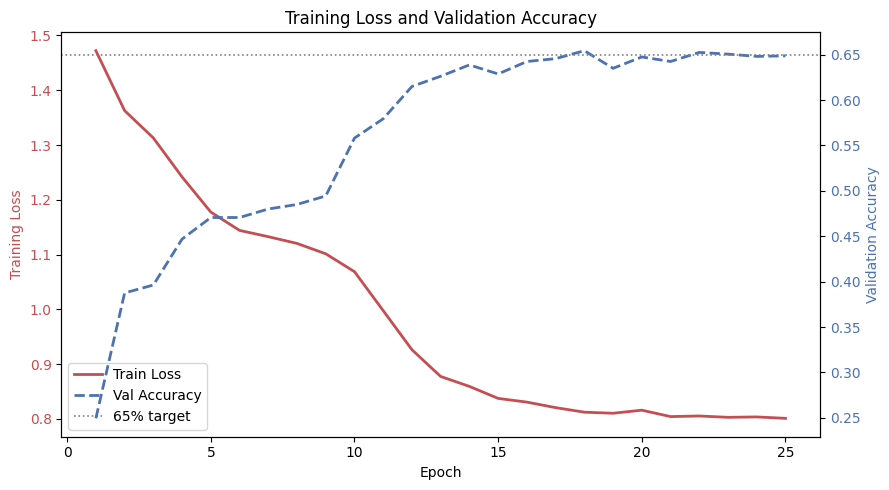

Saved: images/training_curves.png


In [13]:
# Plot 1: Training curves
epochs = range(1, len(history['loss']) + 1)
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color='#C44E52')
ax1.plot(epochs, history['loss'], color='#C44E52', linewidth=2, label='Train Loss')
ax1.tick_params(axis='y', labelcolor='#C44E52')
ax2 = ax1.twinx()
ax2.set_ylabel('Validation Accuracy', color='#4C72B0')
ax2.plot(epochs, history['val_accuracy'], color='#4C72B0', linewidth=2, linestyle='--', label='Val Accuracy')
ax2.axhline(y=0.65, color='gray', linestyle=':', linewidth=1.2, label='65% target')
ax2.tick_params(axis='y', labelcolor='#4C72B0')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
plt.title('Training Loss and Validation Accuracy')
fig.tight_layout()
plt.savefig('images/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/training_curves.png')

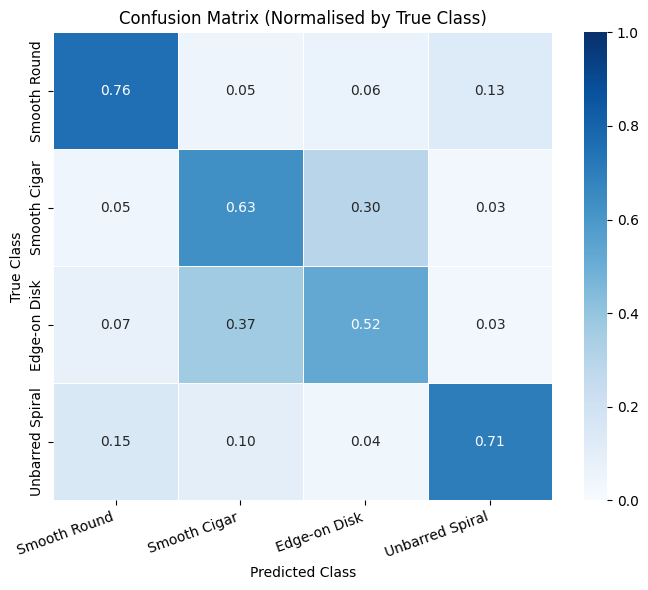

Saved: images/confusion_matrix.png


In [14]:
# Plot 2: Confusion matrix
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_title('Confusion Matrix (Normalised by True Class)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/confusion_matrix.png')

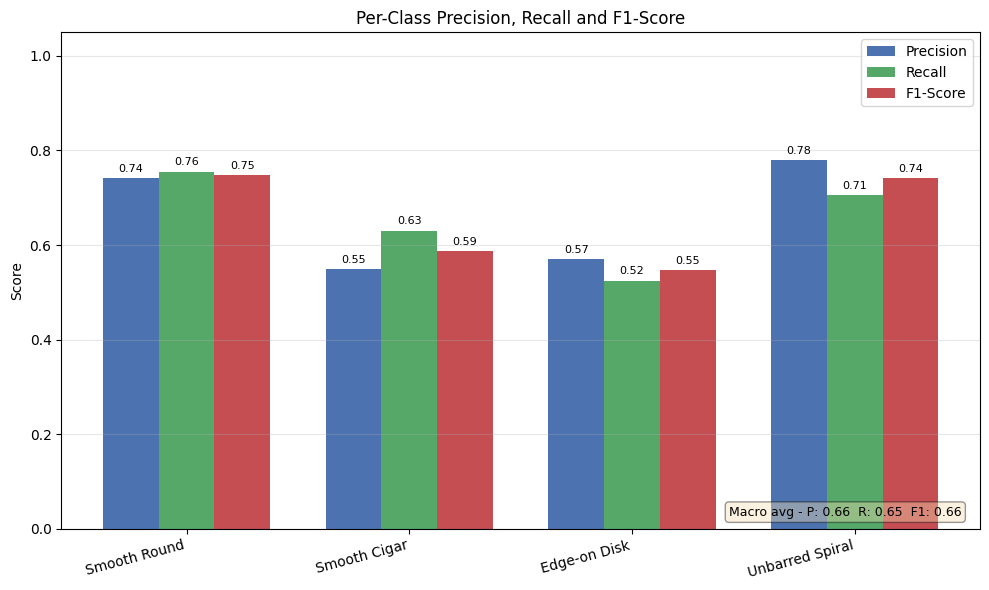

Saved: images/per_class_metrics.png


In [15]:
# Plot 3: Per-class metrics
precision = precision_score(all_labels, all_preds, average=None)
recall    = recall_score(all_labels, all_preds, average=None)
f1        = f1_score(all_labels, all_preds, average=None)
x         = np.arange(len(CLASSES))
width     = 0.25
fig, ax   = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width, precision, width, label='Precision', color='#4C72B0')
b2 = ax.bar(x,         recall,    width, label='Recall',    color='#55A868')
b3 = ax.bar(x + width, f1,        width, label='F1-Score',  color='#C44E52')
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision, Recall and F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
macro_p, macro_r, macro_f = precision.mean(), recall.mean(), f1.mean()
ax.text(0.98, 0.02, f'Macro avg - P: {macro_p:.2f}  R: {macro_r:.2f}  F1: {macro_f:.2f}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))
plt.tight_layout()
plt.savefig('images/per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/per_class_metrics.png')

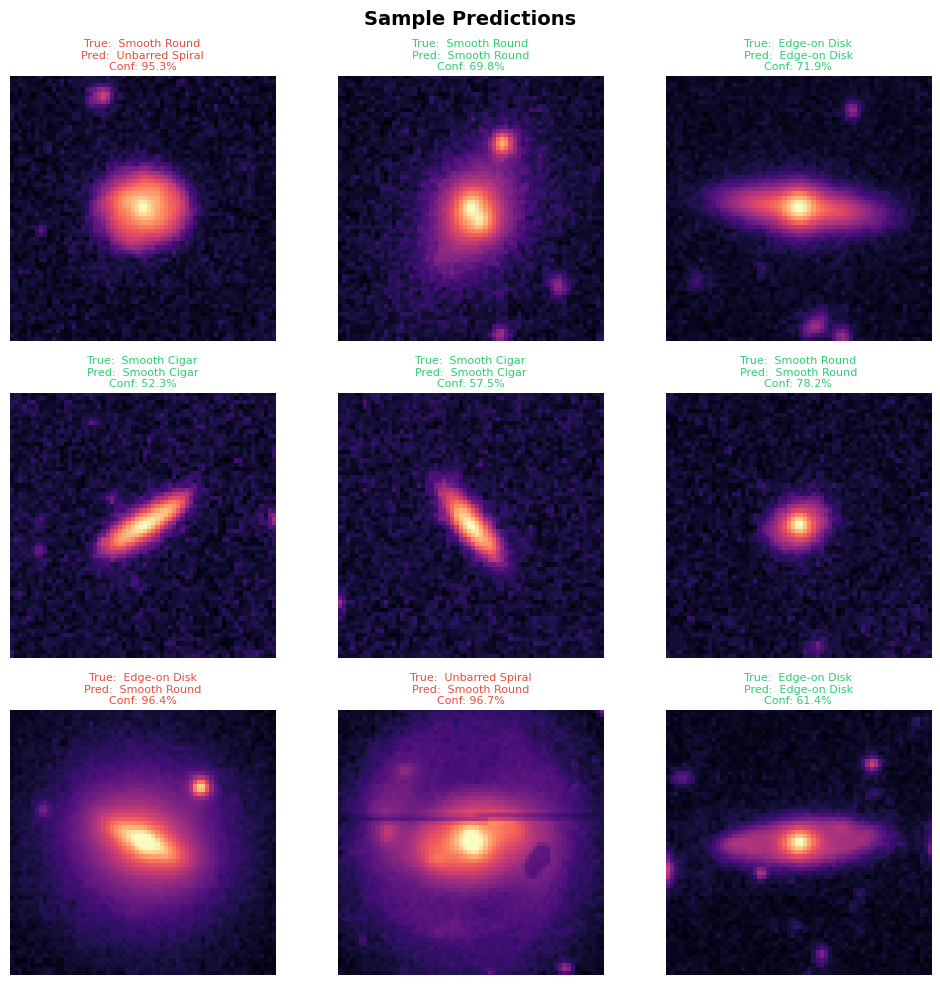

Saved: images/sample_predictions.png


In [16]:
# Plot 4: Sample predictions grid
np.random.seed(RNG_SEED)
correct_idx    = np.where(all_preds == all_labels)[0]
incorrect_idx  = np.where(all_preds != all_labels)[0]
incorrect_conf = all_probs[incorrect_idx].max(dim=1).values.numpy()
top_incorrect  = incorrect_idx[np.argsort(-incorrect_conf)[:3]]
selected = np.concatenate([np.random.choice(correct_idx, 6, replace=False), top_incorrect])
np.random.shuffle(selected)
selected = selected[:9]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('Sample Predictions', fontsize=14, fontweight='bold')
for ax, idx in zip(axes.flat, selected):
    img     = X_test[idx].squeeze().numpy()
    true    = all_labels[idx]
    pred    = all_preds[idx]
    conf    = all_probs[idx][pred].item()
    correct = (true == pred)
    ax.imshow(img, cmap='magma')
    ax.axis('off')
    color = '#2ecc71' if correct else '#e74c3c'
    ax.set_title(f'True:  {CLASSES[true]}\nPred:  {CLASSES[pred]}\nConf: {conf:.1%}',
                 fontsize=8, color=color, pad=4)
plt.tight_layout()
plt.savefig('images/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/sample_predictions.png')

In [18]:
import shutil
import os

# Copy all outputs to Kaggle's output folder
os.makedirs('/kaggle/working/output', exist_ok=True)

shutil.copy('model_params/galaxys4-29070.pth', '/kaggle/working/output/galaxys4-29070.pth')
shutil.copy('images/training_curves.png',      '/kaggle/working/output/training_curves.png')
shutil.copy('images/confusion_matrix.png',     '/kaggle/working/output/confusion_matrix.png')
shutil.copy('images/per_class_metrics.png',    '/kaggle/working/output/per_class_metrics.png')
shutil.copy('images/sample_predictions.png',   '/kaggle/working/output/sample_predictions.png')

print("Files ready to download from Output panel on the right!")

Files ready to download from Output panel on the right!
